In [156]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
import numpy as np

In [157]:
# ========================= PATHS =========================
# 1. Get the absolute path of the folder containing this notebook
NOTEBOOK_DIR = os.path.abspath("")

# 2. Build the absolute path to your dataset folder
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "data_set_generator_for_cnns_only", "data_set"))

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train")
VALID_IMG_DIR = os.path.join(BASE_DIR, "valid")
TEST_IMG_DIR  = os.path.join(BASE_DIR, "test")

TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
VALID_CSV = os.path.join(BASE_DIR, "valid.csv")
TEST_CSV  = os.path.join(BASE_DIR, "test.csv")

# Quick sanity check printouts
print("Checking paths...")
print(f"Train CSV exists: {os.path.exists(TRAIN_CSV)}")
print(f"Train Image Directory exists: {os.path.exists(TRAIN_IMG_DIR)}")
print(f"Valid CSV exists: {os.path.exists(VALID_CSV)}")
print(f"Valid Image Directory exists: {os.path.exists(VALID_IMG_DIR)}")
print(f"Test CSV exists: {os.path.exists(TEST_CSV)}")
print(f"Test Image Directory exists: {os.path.exists(TEST_IMG_DIR)}")

Checking paths...
Train CSV exists: True
Train Image Directory exists: True
Valid CSV exists: True
Valid Image Directory exists: True
Test CSV exists: True
Test Image Directory exists: True


In [158]:

# ========================= CONFIG =========================
IMAGE_HEIGHT = 40
IMAGE_WIDTH = 160
BATCH_SIZE = 16
EPOCHS = 50


In [159]:
import os
import pandas as pd

def clean_csv_by_removing_missing_images(csv_path, img_dir, split_name="Dataset"):
    print(f"=== Cleaning {split_name.upper()} Split ===")
    
    if not os.path.exists(csv_path):
        print(f"❌ Skipping {split_name}: CSV file does not exist at {csv_path}\n")
        return
    if not os.path.exists(img_dir):
        print(f"❌ Skipping {split_name}: Image directory does not exist at {img_dir}\n")
        return

    # 1. Load the current CSV
    df = pd.read_csv(csv_path)
    original_row_count = len(df)
    
    # 2. Check which images actually exist on your hard drive right now
    # It creates a True/False mask: True if file exists, False if it's missing
    image_exists_mask = df['image'].apply(lambda x: os.path.exists(os.path.join(img_dir, str(x))))
    
    # 3. Filter the dataframe to ONLY keep rows where the image exists
    cleaned_df = df[image_exists_mask]
    removed_rows_count = original_row_count - len(cleaned_df)
    
    # 4. Overwrite the CSV file with the cleaned version
    cleaned_df.to_csv(csv_path, index=False)
    
    print(f"📊 Original rows in CSV: {original_row_count}")
    print(f"🔥 Removed {removed_rows_count} rows because their images were missing.")
    print(f"✅ Saved cleaned CSV with {len(cleaned_df)} remaining rows.")
    print("-" * 40 + "\n")

# Run this cleanup across all three of your dataset splits
clean_csv_by_removing_missing_images(TRAIN_CSV, TRAIN_IMG_DIR, "Train")
clean_csv_by_removing_missing_images(VALID_CSV, VALID_IMG_DIR, "Validation")
clean_csv_by_removing_missing_images(TEST_CSV, TEST_IMG_DIR, "Test")

=== Cleaning TRAIN Split ===
📊 Original rows in CSV: 1270
🔥 Removed 0 rows because their images were missing.
✅ Saved cleaned CSV with 1270 remaining rows.
----------------------------------------

=== Cleaning VALIDATION Split ===
📊 Original rows in CSV: 173
🔥 Removed 0 rows because their images were missing.
✅ Saved cleaned CSV with 173 remaining rows.
----------------------------------------

=== Cleaning TEST Split ===
📊 Original rows in CSV: 212
🔥 Removed 0 rows because their images were missing.
✅ Saved cleaned CSV with 212 remaining rows.
----------------------------------------



In [160]:
# ====================== PREPROCESS ======================\n",
def preprocess_image(image_path):
    # Remove the broad try-except; let TensorFlow handle paths natively
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMAGE_HEIGHT, IMAGE_WIDTH])
    return tf.cast(img, tf.float32) / 255.0


def parse_data(row, image_dir):
    # 1. Build image path and preprocess normally
    img_path = tf.strings.join([image_dir, row['image']], separator=os.sep)
    image = preprocess_image(img_path)
    
    # 2. Python safe fallback function to handle padding and splitting cleanly
    def python_split_label(label_tensor):
        # Convert the tensor input to a standard Python integer, then string
        raw_val = str(int(label_tensor.numpy()))
        # Pad it out to exactly 5 digits: e.g., '19' becomes '00019'
        padded_val = raw_val.zfill(5)
        # Convert each character into an individual integer digit
        return [int(padded_val[0]), int(padded_val[1]), int(padded_val[2]), int(padded_val[3]), int(padded_val[4])]

    # 3. Inject the Python function safely directly into the TensorFlow Graph
    d1, d2, d3, d4, d5 = tf.py_function(
        func=python_split_label,
        inp=[row['label']],
        Tout=[tf.int32, tf.int32, tf.int32, tf.int32, tf.int32]
    )
    
    # 4. Enforce explicit 0-D scalar shapes for Keras multi-output tracking
    d1.set_shape([])
    d2.set_shape([])
    d3.set_shape([])
    d4.set_shape([])
    d5.set_shape([])

    return image, {
        'digit1': d1, 'digit2': d2, 'digit3': d3, 'digit4': d4, 'digit5': d5
    }
# --- FIX: Enforce 5-digit string labels in Pandas dataframes ---
df_train['label'] = df_train['label'].astype(int).astype(str).str.zfill(5)
df_valid['label'] = df_valid['label'].astype(int).astype(str).str.zfill(5)
df_test['label']  = df_test['label'].astype(int).astype(str).str.zfill(5)

# 3. Create datasets cleanly from the verified rows
train_ds = create_dataset(df_train, TRAIN_IMG_DIR, shuffle=False)
val_ds   = create_dataset(df_valid, VALID_IMG_DIR, shuffle=False)
test_ds  = create_dataset(df_test, TEST_IMG_DIR, shuffle=False)


def create_dataset(df, image_dir, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(dict(df))
    
    if shuffle:
        ds = ds.shuffle(buffer_size=512)   # Fixed number instead of len(df)
    
    ds = ds.map(lambda row: parse_data(row, image_dir), 
                num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [161]:
# ========================= LOAD DATA (FAIL-SAFE) =========================
print("Loading datasets safely...")
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)
df_test  = pd.read_csv(TEST_CSV)

# 1. Filter out training rows where the image file is physically missing from disk
train_mask = df_train['image'].apply(lambda x: os.path.exists(os.path.join(TRAIN_IMG_DIR, str(x))))
missing_train = len(df_train) - train_mask.sum()
if missing_train > 0:
    print(f"⚠️ Warning: {missing_train} rows in train.csv don't have matching files on disk. Skipping them.")
df_train = df_train[train_mask]

# 2. Filter out validation rows where the image file is physically missing from disk
valid_mask = df_valid['image'].apply(lambda x: os.path.exists(os.path.join(VALID_IMG_DIR, str(x))))
missing_valid = len(df_valid) - valid_mask.sum()
if missing_valid > 0:
    print(f"⚠️ Warning: {missing_valid} rows in valid.csv don't have matching files on disk. Skipping them.")
df_valid = df_valid[valid_mask]
test_mask = df_test['image'].apply(lambda x: os.path.exists(os.path.join(TEST_IMG_DIR, str(x))))
missing_test = len(df_test) - test_mask.sum()


# 3. Create datasets cleanly from the verified rows
train_ds = create_dataset(df_train, TRAIN_IMG_DIR, shuffle=False)
val_ds   = create_dataset(df_valid, VALID_IMG_DIR, shuffle=False)
test_ds  = create_dataset(df_test, TEST_IMG_DIR, shuffle=False)

print(f"\nFinal Ready Samples -> Train: {len(df_train)} | Val: {len(df_valid)} | Test: {len(df_test)}")

Loading datasets safely...

Final Ready Samples -> Train: 1270 | Val: 173 | Test: 212


In [172]:
def create_multidigit_model():
    inputs = layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 1))
    
    # Block 1
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    # Block 2
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2, 2))(x)
    x = layers.Dropout(0.2)(x)
    
    
    
    # Neck / Flatten layer
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x) # Aggressive dropout here stops the 5.23 loss explosion
    
    # 5 Separate Output Branches (one for each digit)
    # Each outputs 10 classes (digits 0-9) with softmax activation
    out1 = layers.Dense(10, activation='softmax', name='digit1')(x)
    out2 = layers.Dense(10, activation='softmax', name='digit2')(x)
    out3 = layers.Dense(10, activation='softmax', name='digit3')(x)
    out4 = layers.Dense(10, activation='softmax', name='digit4')(x)
    out5 = layers.Dense(10, activation='softmax', name='digit5')(x)
    
    model = models.Model(inputs=inputs, outputs=[out1, out2, out3, out4, out5])
    return model

model = create_multidigit_model()
model.summary()

Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 40, 160,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_42 (Conv2D)  │ (None, 40, 160,   │        160 │ input_layer_4[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 160,   │         64 │ conv2d_42[0][0]   │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_42    │ (None, 20, 80,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_56          │ (None, 20, 80,    │          0 │ max_pooling2d_42… │
│ (Dropout)           │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_43 (Conv2D)  │ (None, 20, 80,    │      4,640 │ dropout_56[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 80,    │        128 │ conv2d_43[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_43    │ (None, 10, 40,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_57          │ (None, 10, 40,    │          0 │ max_pooling2d_43… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_14          │ (None, 12800)     │          0 │ dropout_57[0][0]  │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │    819,264 │ flatten_14[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_14[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_58          │ (None, 64)        │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ digit1 (Dense)      │ (None, 10)        │        650 │ dropout_58[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ digit2 (Dense)      │ (None, 10)        │        650 │ dropout_58[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ digit3 (Dense)      │ (None, 10)        │        650 │ dropout_58[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ digit4 (Dense)      │ (None, 10)        │        650 │ dropout_58[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ digit5 (Dense)      │ (None, 10)        │        650 │ dropout_58[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 827,762 (3.16 MB)

 Trainable params: 827,538 (3.16 MB)

 Non-trainable params: 224 (896.00 B)

In [173]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    # Loss must be sparse because your labels are integers (0-9)
    loss={
        'digit1': 'sparse_categorical_crossentropy',
        'digit2': 'sparse_categorical_crossentropy',
        'digit3': 'sparse_categorical_crossentropy',
        'digit4': 'sparse_categorical_crossentropy',
        'digit5': 'sparse_categorical_crossentropy'
    },
    # This lets you see the explicit accuracy for every single digit place during training
    metrics={
        'digit1': 'accuracy',
        'digit2': 'accuracy',
        'digit3': 'accuracy',
        'digit4': 'accuracy',
        'digit5': 'accuracy'
    }
)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    # Stops training if validation loss doesn't improve for 5 epochs
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    # Lowers learning rate if progress stalls, helping the model converge cleaner
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100, # Set it higher; EarlyStopping will handle shutting it down safely
    callbacks=callbacks
)

Epoch 1/100
11/80 ━━━━━━━━━━━━━━━━━━━━ 8s 119ms/step - digit1_accuracy: 0.0795 - digit1_loss: 3.2417 - digit2_accuracy: 0.1307 - digit2_loss: 3.1491 - digit3_accuracy: 0.1307 - digit3_loss: 3.1852 - digit4_accuracy: 0.0852 - digit4_loss: 3.4085 - digit5_accuracy: 0.1136 - digit5_loss: 3.2385 - loss: 16.2363

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


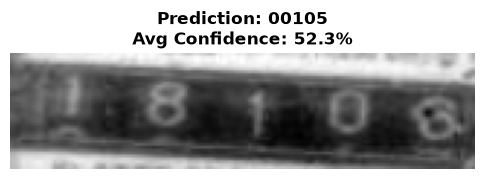

In [171]:
import numpy as np

# Select your test image path
IMAGE_PATH = os.path.join(TEST_IMG_DIR, "75230801377_crop_0.png")

def prepare_single_image(img_path):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: raise FileNotFoundError(f"Missing file: {img_path}")
    img_resized = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT))
    return img_resized, np.expand_dims(img_resized.astype(np.float32) / 255.0, axis=(0, -1))

try:
    display_img, input_tensor = prepare_single_image(IMAGE_PATH)
    predictions = model.predict(input_tensor)
    
    # Dynamic dict vs list unpacking
    if isinstance(predictions, dict):
        digits = [predictions[f'digit{i}'][0] for i in range(1, 6)]
    else:
        digits = [predictions[i][0] for i in range(5)]
        
    final_reading = "".join(str(np.argmax(d)) for d in digits)
    confidence_scores = [np.max(d) * 100 for d in digits]
    
    plt.figure(figsize=(6, 3))
    plt.imshow(display_img, cmap='gray')
    plt.title(f"Prediction: {final_reading}\nAvg Confidence: {np.mean(confidence_scores):.1f}%", fontsize=12, fontweight='bold')
    plt.axis('off')
    plt.show()

except Exception as e:
    print(f"Prediction Error: {e}")

In [166]:

model.save("captcha_model_final.keras")
print("✅ Training completed!")

✅ Training completed!
